## 1. Importación de Dependencias y Carga de Datos
Se importan las librerías necesarias y se cargan los conjuntos de datos preprocesados.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PATH_TRAIN = 'dataset/processed/dataset_entrenamiento.csv'
PATH_VAL = 'dataset/processed/dataset_validacion.csv'
PATH_TEST = 'dataset/processed/dataset_prueba.csv'

df_train = pd.read_csv(PATH_TRAIN)
df_val = pd.read_csv(PATH_VAL)
df_test = pd.read_csv(PATH_TEST)

print(f"-> Set de Entrenamiento (2025):  {df_train.shape[0]} filas | {df_train.shape[1]} columnas")
print(f"-> Set de Validación (2026-V):   {df_val.shape[0]} filas | {df_val.shape[1]} columnas")
print(f"-> Set de Prueba (2026-O):       {df_test.shape[0]} filas | {df_test.shape[1]} columnas")

-> Set de Entrenamiento (2025):  144018 filas | 23 columnas
-> Set de Validación (2026-V):   27374 filas | 23 columnas
-> Set de Prueba (2026-O):       27374 filas | 23 columnas


## 2. Definición de Variables Predictoras y Objetivo
Se remueven las columnas que no aportan al modelamiento y se separan las características (X) de la variable objetivo (y).

In [2]:
columnas_a_descartar = [
    '_id', 'Fecha', 'ID region', 'Region', 
    'Unidad de comercializacion', 'Precio minimo', 
    'Precio maximo', 'Precio promedio', 'Precio_Promedio_Limpio', 'Volumen',
    'Dia_Semana_Nombre'
]

X_train = df_train.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_train = df_train['Precio_Promedio_Por_Kilo']

X_val = df_val.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_val = df_val['Precio_Promedio_Por_Kilo']

X_test = df_test.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_test = df_test['Precio_Promedio_Por_Kilo']

print(f"Dimensiones de X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

Dimensiones de X_train: (144018, 11) | X_val: (27374, 11) | X_test: (27374, 11)


## 3. Configuración del Preprocesamiento (ColumnTransformer)
Se define el pipeline de transformación de variables: One-Hot Encoding para variables categóricas de baja cardinalidad, Target Encoding regularizado para alta cardinalidad y StandardScaler para variables numéricas.

In [3]:
cat_baja = ['Subsector', 'Estacion']
cat_alta = ['Mercado', 'Producto', 'Variedad / Tipo', 'Calidad', 'Origen']
numeric_features = ['Volumen_Limpio', 'weight_kg', 'Mes', 'Dia_Semana']

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat_baja",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            cat_baja
        ),
        (
            "cat_alta",
            TargetEncoder(smooth="auto", cv=5, random_state=42),
            cat_alta
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

## 4. Definición de Modelos y Construcción de Pipelines
Se definen los estimadores Ridge y Lasso (con un alpha optimizado para la escala del precio) y se encapsulan en pipelines junto con el preprocesador.

In [4]:
model_ridge = Ridge(alpha=1.0, random_state=42)
model_lasso = Lasso(alpha=20.0, random_state=42) # alpha=20.0 es óptimo para la escala de precios CLP

pipeline_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_ridge)
])

pipeline_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_lasso)
])

## 5. Entrenamiento de los Modelos
Se ajustan ambos pipelines utilizando el conjunto de datos de entrenamiento.

In [5]:
print("Entrenando el Pipeline de Regresión Ridge...")
pipeline_ridge.fit(X_train, y_train)

print("Entrenando el Pipeline de Regresión Lasso...")
pipeline_lasso.fit(X_train, y_train)

print("-> Entrenamiento completado.")

Entrenando el Pipeline de Regresión Ridge...


/home/francisco/Documentos/IngDatos/proyecto_grupo/prediccion_precio_promedio_hortifruticula/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Entrenando el Pipeline de Regresión Lasso...


/home/francisco/Documentos/IngDatos/proyecto_grupo/prediccion_precio_promedio_hortifruticula/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


-> Entrenamiento completado.


## 6. Evaluación en el Conjunto de Validación
Se obtienen predicciones sobre el conjunto de validación y se comparan las métricas MAE, RMSE y R² de ambos modelos.

In [6]:
preds_ridge = pipeline_ridge.predict(X_val)
preds_lasso = pipeline_lasso.predict(X_val)

mae_ridge = mean_absolute_error(y_val, preds_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, preds_ridge))
r2_ridge = r2_score(y_val, preds_ridge)

mae_lasso = mean_absolute_error(y_val, preds_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_val, preds_lasso))
r2_lasso = r2_score(y_val, preds_lasso)

print("=== RENDIMIENTO REGRESIÓN RIDGE (VALIDACIÓN) ===")
print(f"MAE : ${mae_ridge:.2f} CLP/Kg")
print(f"RMSE: ${rmse_ridge:.2f} CLP/Kg")
print(f"R²  : {r2_ridge * 100:.2f}%")

print("\n=== RENDIMIENTO REGRESIÓN LASSO (VALIDACIÓN) ===")
print(f"MAE : ${mae_lasso:.2f} CLP/Kg")
print(f"RMSE: ${rmse_lasso:.2f} CLP/Kg")
print(f"R²  : {r2_lasso * 100:.2f}%")

=== RENDIMIENTO REGRESIÓN RIDGE (VALIDACIÓN) ===
MAE : $327.52 CLP/Kg
RMSE: $451.28 CLP/Kg
R²  : 74.37%

=== RENDIMIENTO REGRESIÓN LASSO (VALIDACIÓN) ===
MAE : $326.62 CLP/Kg
RMSE: $451.57 CLP/Kg
R²  : 74.34%


## 7. Análisis de Coeficientes de Lasso (Selección de Variables)
Se analizan los coeficientes del modelo Lasso para identificar qué características fueron penalizadas a cero y cuáles tienen mayor relevancia lineal.

=== RADIOGRAFÍA DE SELECCIÓN DE VARIABLES (LASSO) ===
-> Variables penalizadas y eliminadas por Lasso (Peso = 0): 7
['cat_baja__Estacion_Primavera', 'cat_baja__Estacion_Otoño', 'cat_baja__Subsector_Hortalizas y tubérculos', 'cat_baja__Estacion_Verano', 'num__Volumen_Limpio', 'num__Mes', 'num__Dia_Semana']


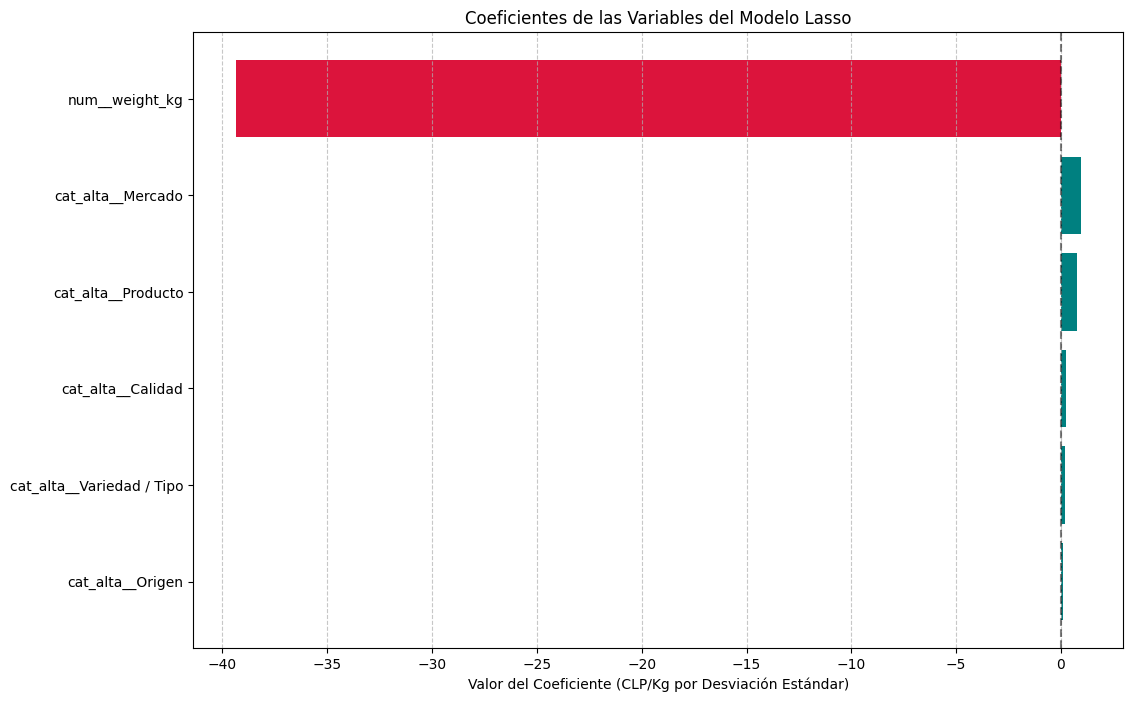

In [7]:
coefs = pipeline_lasso.named_steps["model"].coef_
feature_names = pipeline_lasso.named_steps["preprocessor"].get_feature_names_out()

df_importancia = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coefs,
    "Importancia_Absoluta": np.abs(coefs)
}).sort_values(by="Importancia_Absoluta", ascending=False)

# Variables eliminadas (coeficiente = 0)
eliminadas = df_importancia[df_importancia["Importancia_Absoluta"] < 1e-5]["Variable"].tolist()
print("=== RADIOGRAFÍA DE SELECCIÓN DE VARIABLES (LASSO) ===")
print(f"-> Variables penalizadas y eliminadas por Lasso (Peso = 0): {len(eliminadas)}")
print(eliminadas)

# Graficar coeficientes no nulos
df_plot = df_importancia[df_importancia["Importancia_Absoluta"] >= 1e-5]
plt.figure(figsize=(12, 8))
colors = ['teal' if c > 0 else 'crimson' for c in df_plot['Coeficiente']]
plt.barh(df_plot['Variable'], df_plot['Coeficiente'], color=colors)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Coeficientes de las Variables del Modelo Lasso")
plt.xlabel("Valor del Coeficiente (CLP/Kg por Desviación Estándar)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 8. Evaluación Final y Visualización de Resultados en el Conjunto de Prueba
Se evalúa el rendimiento del modelo óptimo (Lasso) en el conjunto de prueba y se genera el gráfico de valores reales vs predichos.

=== RENDIMIENTO FINAL EN EL DATASET DE PRUEBA (LASSO) ===
MAE  : 344.36 CLP/Kg
MSE  : 296891.91
RMSE : 544.88 CLP/Kg
R²   : 72.40%


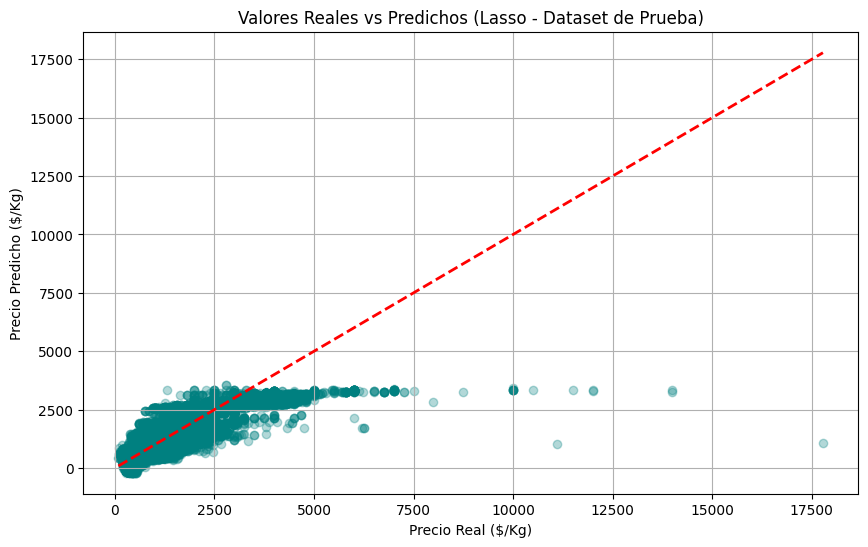


Modelo Lasso guardado exitosamente como modelo_ridge_lasso.pkl


In [8]:
preds_test = pipeline_lasso.predict(X_test)

mae_test = mean_absolute_error(y_test, preds_test)
mse_test = mean_squared_error(y_test, preds_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, preds_test)

print("=== RENDIMIENTO FINAL EN EL DATASET DE PRUEBA (LASSO) ===")
print(f"MAE  : {mae_test:.2f} CLP/Kg")
print(f"MSE  : {mse_test:.2f}")
print(f"RMSE : {rmse_test:.2f} CLP/Kg")
print(f"R²   : {r2_test * 100:.2f}%")

# Gráfico de Valores Reales vs Predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds_test, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Precio Real ($/Kg)")
plt.ylabel("Precio Predicho ($/Kg)")
plt.title("Valores Reales vs Predichos (Lasso - Dataset de Prueba)")
plt.grid(True)
plt.show()

# Guardamos el modelo ganador
joblib.dump(pipeline_lasso, "modelo_ridge_lasso.pkl")
print("\nModelo Lasso guardado exitosamente como modelo_ridge_lasso.pkl")